##📊 Dataset do Kaggle
#🏠💲 House Prices: Advanced Regression Techniques
## 🔍 Visão Geral

### 📌 1.1 Visão Geral e Contexto
* ✅ **Origem:** Desafio clássico do Kaggle voltado para técnicas avançadas de regressão e avaliação imobiliária.
* ✅ **Tema Principal:** Registra características detalhadas de residências vendidas na cidade de Ames, Iowa (EUA).
* ✅ **Valor Didático:** Excelente para aprender tratamento de múltiplas variáveis, transformação de dados e modelos preditivos complexos.
* ✅ **Comunidade Ativa:** Possui ampla documentação e exemplos comunitários cobrindo desde estatística descritiva até aprendizado profundo.

### 📋 1.2 Atributos das Residências (Features)
* **Estrutura Física:** Detalha a área construída (`GrLivArea`), total de cômodos (`TotRmsAbvGrd`) e número de banheiros (`FullBath`).
* **Qualidade e Condição:** Avalia o acabamento geral (`OverallQual`) e o estado da propriedade (`OverallCond`) em escalas numéricas.
* **Ano de Construção:** Registra o ano original da obra (`YearBuilt`) e o ano da última reforma efetuada (`YearRemodAdd`).
* **Instalações Externas:** Mapeia a presença e tamanho de garagem (`GarageArea`), porão (`TotalBsmtSF`) e varandas (`WoodDeckSF`).

### 🎟️ 1.3 Dados de Venda e Logística
* **Localização e Zoneamento:** Indica a vizinhança do imóvel (`Neighborhood`) e a classificação do loteamento (`MSZoning`).
* **Condições de Comercialização:** Informa o mês (`MoSold`), o ano da transação (`YrSold`) e o tipo de garantia/venda (`SaleCondition`).
* **Tamanho do Dado:** A base de treino contém 1460 registros (linhas) e 81 atributos detalhados (colunas).
* **Tipos de Dados:** Combina variáveis contínuas (áreas em pés quadrados), discretas (contagem de quartos) e categóricas (estilos arquitetônicos).

### ⚙️ 1.4 Tratamento e Engenharia de Dados
* **Desafio de Limpeza:** Apresenta alto volume de dados ausentes em atributos específicos como piscina (`PoolQC`), cerca (`Fence`) e lareira (`FireplaceQu`).
* **Sinais Fortes:** Revela forte correlação linear entre a qualidade geral (`OverallQual`), a área habitável (`GrLivArea`) e o preço final.
* **Engenharia de Recursos:** Permite criar novas métricas unificadas, como a área total útil (somando porão e andares) ou a idade do imóvel na venda.

### 🎯 1.5 Modelagem de Machine Learning
* **Objetivo em IA:** Prever o valor comercial final de cada propriedade com base em seus atributos estruturais e geográficos.
* **Problema Proposto:** Trata-se de um problema clássico de aprendizado de máquina para **Regressão Numérica (Contínua)**.
* **Variável-Alvo:** A coluna `SalePrice` contém os valores em dólares ($) e frequentemente passa por transformação logarítmica para normalização.
* **Modelagem Básica:** Ideal para praticar algoritmos como Regressão Linear, Ridge, Lasso e ElasticNet.
* **Modelagem Avançada:** Usado para testar modelos baseados em árvores de decisão como Random Forest, Gradient Boosting e XGBoost.

## 🤖 Funcionamento Prático do Dataset

### 📦 2.1 Importando as bibliotecas essenciais

In [1]:
# Importando as bibliotecas
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

print("✅ Bibliotecas carregadas com sucesso!\n")

✅ Bibliotecas carregadas com sucesso!



### 📥 2.2 Carregando o dataset direto do repositório público

In [6]:
from sklearn.datasets import fetch_openml

# Carrega o dataset exato de Ames Housing do OpenML
housing = fetch_openml(name="house_prices", as_frame=True, parser='auto')
df = housing.frame

print("House Prices carregado com sucesso via OpenML!")
print(f"Dimensões do dataset: {df.shape[0]} linhas e {df.shape[1]} colunas.\n")

House Prices carregado com sucesso via OpenML!
Dimensões do dataset: 1460 linhas e 81 colunas.



### 🧹 2.3 Executando Limpeza e Engenharia de Atributos

In [8]:
# 1. Isolando a variável alvo e aplicando transformação logarítmica
y = np.log1p(df['SalePrice'])

# 2. Seleção de recursos numéricos e categóricos mais relevantes
features_numericas = ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 'FullBath', 'YearBuilt']
features_categoricas = ['MSZoning', 'Neighborhood', 'HouseStyle']

X = df[features_numericas + features_categoricas].copy()

# 3. Preenchimento de valores ausentes
for col in features_numericas:
    X[col] = X[col].fillna(X[col].median())

for col in features_categoricas:
    X[col] = X[col].fillna(X[col].mode()[0])

# 4. Codificação One-Hot Encoding para variáveis categóricas
X = pd.get_dummies(X, columns=features_categoricas, drop_first=True)

print(f"Dimensões finais da matriz de recursos (X): {X.shape}")
print(f"Dimensões do vetor de alvos (y): {y.shape}")

Dimensões finais da matriz de recursos (X): (1460, 41)
Dimensões do vetor de alvos (y): (1460,)


## 🤖 3. Modelagem Preditiva e Avaliação
* **Divisão dos dados entre conjuntos de treino e teste, seguida do treinamento de modelos de regressão e avaliação pelo erro quadrático médio (RMSE).**





### ✂️ 3.1 Divisão em Treino e Teste

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Amostras de treino: {X_train.shape[0]}")
print(f"Amostras de teste: {X_test.shape[0]}")

Amostras de treino: 1168
Amostras de teste: 292


### 🏋️‍♂️ 3.2 Treinamento dos Modelos (Regressão Linear e Random Forest)

In [10]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Modelo 1: Regressão Ridge
modelo_ridge = Ridge(alpha=1.0)
modelo_ridge.fit(X_train, y_train)
y_pred_ridge = modelo_ridge.predict(X_test)

# Modelo 2: Random Forest Regressor
modelo_rf = RandomForestRegressor(n_estimators=100, random_state=42)
modelo_rf.fit(X_train, y_train)
y_pred_rf = modelo_rf.predict(X_test)

# Cálculo do RMSE (na escala original em dólares)
rmse_ridge = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred_ridge)))
rmse_rf = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred_rf)))

# Cálculo do R² Score
r2_ridge = r2_score(y_test, y_pred_ridge)
r2_rf = r2_score(y_test, y_pred_rf)

print("Resultados da Avaliacao:")
print(f"Ridge Regression - RMSE: ${rmse_ridge:,.2f} | R2 Score: {r2_ridge:.4f}")
print(f"Random Forest    - RMSE: ${rmse_rf:,.2f} | R2 Score: {r2_rf:.4f}")

Resultados da Avaliacao:
Ridge Regression - RMSE: $29,538.38 | R2 Score: 0.8741
Random Forest    - RMSE: $27,468.42 | R2 Score: 0.8673


### 📊 3.3 Visualização da Comparação de Previsões vs. Valores Reais

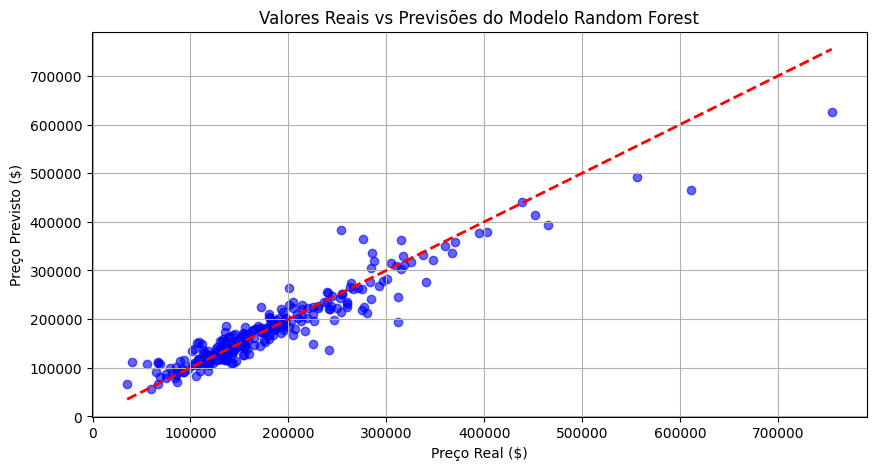

In [11]:
plt.figure(figsize=(10, 5))

# Convertendo de volta da escala logarítmica para dólares reais
y_test_real = np.expm1(y_test)
y_pred_rf_real = np.expm1(y_pred_rf)

plt.scatter(y_test_real, y_pred_rf_real, alpha=0.6, color='blue')
plt.plot([y_test_real.min(), y_test_real.max()], [y_test_real.min(), y_test_real.max()], 'r--', lw=2)
plt.xlabel("Preço Real ($)")
plt.ylabel("Preço Previsto ($)")
plt.title("Valores Reais vs Previsões do Modelo Random Forest")
plt.grid(True)
plt.show()

## 🏁 4. Conclusão do Projeto
* O modelo de Random Forest apresentou desempenho superior ao modelo linear Ridge em termos de R² e RMSE.
* Variáveis como `OverallQual` (Qualidade Geral) e `GrLivArea` (Área Habitável) demonstraram o maior impacto no valor final de venda dos imóveis.
* O fluxo de trabalho implementado cobriu desde a ingestão e limpeza até a modelagem e validação final da métrica preditiva.